# Algoritmos

## Gerando dados

In [54]:
from joblib import load, dump

In [55]:
import os
try:
    os.chdir("aulas_teoricas")
except FileNotFoundError:
    pass

os.listdir("./")

['00-divisão_dados_2026-07-14.ipynb',
 '01-aula-03_2026-07-14.ipynb',
 '02-aula-04_2026-07-14.ipynb',
 '03-aula-05_01-dados_2026-07-14.ipynb',
 '03-aula-05_02-cluster_2026-07-14.ipynb',
 '03-aula-05_03-classif_2026-07-14.ipynb',
 '03-aula-05_04-regressão_2026-07-14.ipynb',
 '03-aula-05_05_analise_2026-07-14.ipynb',
 '04-aula-06-divisão de dados_2026-07-14.ipynb',
 'data',
 'SMOTE.ipynb',
 'src',
 'ydata-profiling.ipynb']

In [56]:
df_1 = load('./data/05_aula_df_1')
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o


## k-means

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import silhouette_score

In [58]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score

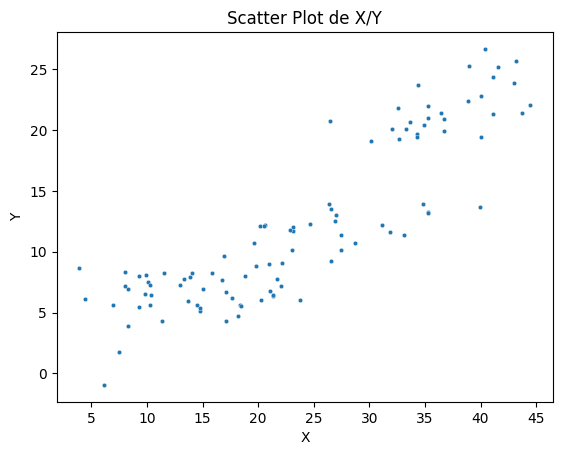

In [59]:
x = 'x_noise'
y = 'y_noise_new'
s = 10
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    data=df_1,
)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [60]:
def ponto_estrela(df_sample: pd.DataFrame, x: str, y: str) -> tuple:
    x_estrela = np.random.randint(
        np.min(df_sample[x]),
        np.max(df_sample[x]),
    )
    y_estrela = np.random.randint(
        np.min(df_sample[y]),
        np.max(df_sample[y]),
    )
    return x_estrela, y_estrela

def seta_estrela(
        df_sample: pd.DataFrame,
        x: str,
        y: str,
        color: str = 'g',
        seta: bool = False,
        n_setas: int = 5) -> None:
    sns.scatterplot(
        x=x,
        y=y,
        s=s,
        color='b',
        data=df_sample,
    )
    x_estrela, y_estrela = ponto_estrela(df_sample, x, y)
    plt.plot(
        x_estrela,
        y_estrela,
        '*' + color,
        markersize=15
    )
    if seta:
        for _ in range(n_setas):
            index = df_sample[x].sample(1).index[0]
            dx = df_sample[x][index] - x_estrela
            dy = df_sample[y][index] - y_estrela
            plt.arrow(
                x_estrela,
                y_estrela, 
                dx,
                dy,
                head_width=1,
                head_length=1,
                length_includes_head=True,
                color=color,
            )
    return None

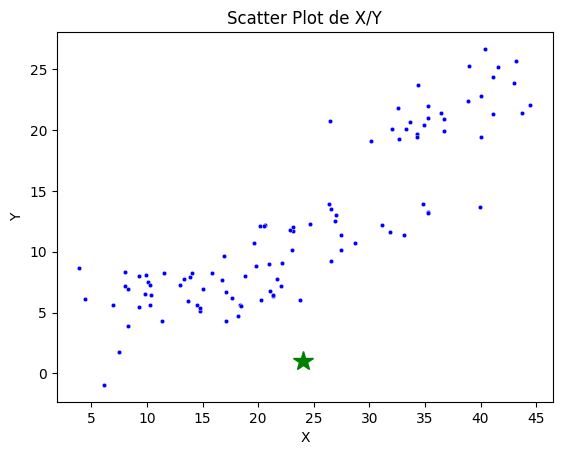

In [61]:
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new'
}
seta_estrela(**grafico)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

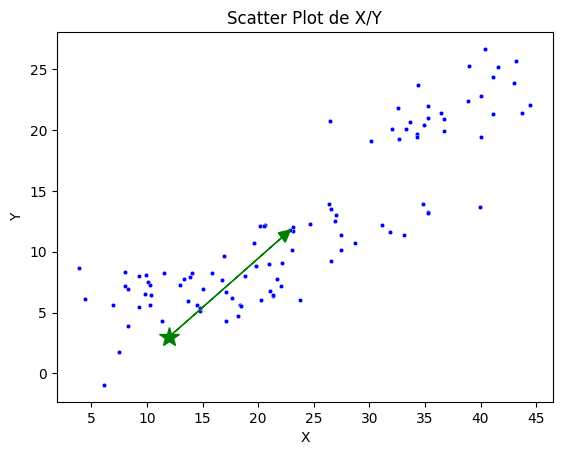

In [62]:
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new',
    'seta': True,
    'n_setas': 1
}
seta_estrela(**grafico)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

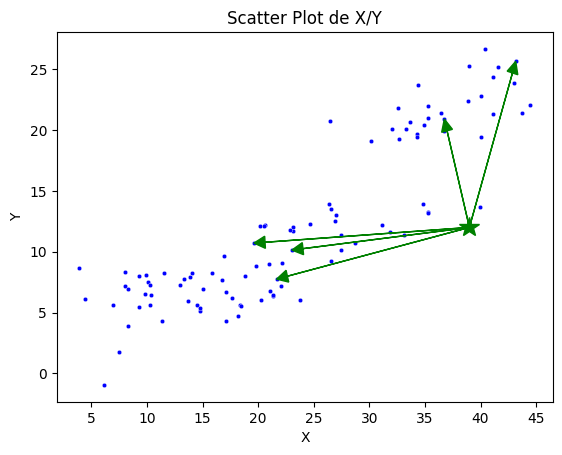

In [63]:
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new',
    'seta': True,
}
seta_estrela(**grafico)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

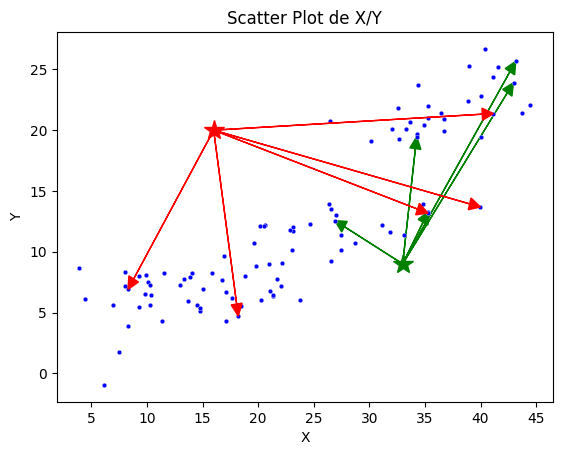

In [64]:
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new',
    'seta': True,
}
seta_estrela(**grafico)
grafico = {
    "df_sample": df_1,
    'x': 'x_noise',
    'y': 'y_noise_new',
    'color': 'r',
    'seta': True,
}
seta_estrela(**grafico)
plt.title('Scatter Plot de X/Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [65]:
scaler = MinMaxScaler()
normalized_scaler = scaler.fit_transform(df_1[[x, y]])
normalized_scaler[:5]

array([[0.91661725, 0.91589701],
       [0.14658658, 0.32585629],
       [0.8084255 , 0.75530498],
       [0.23138147, 0.31420104],
       [0.33919258, 0.25914505]])

In [66]:
df_1[x+'_normalized'] = normalized_scaler[:, 0]
df_1[y+'_normalized'] = normalized_scaler[:, 1]
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_normalized,y_noise_new_normalized
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,0.916617,0.915897
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,0.146587,0.325856
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,0.808425,0.755305
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,0.231381,0.314201
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,0.339193,0.259145


In [67]:
scaler = StandardScaler()
standard_features = scaler.fit_transform(df_1[[x, y]])
standard_features[:5]

array([[ 1.57364483,  1.8314633 ],
       [-1.2540686 , -0.61485802],
       [ 1.17634214,  1.16564535],
       [-0.94268406, -0.66318093],
       [-0.54677913, -0.89144423]])

In [68]:
df_1[x+'_standard'] = standard_features[:, 0]
df_1[y+'_standard'] = standard_features[:, 1]
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_normalized,y_noise_new_normalized,x_noise_standard,y_noise_new_standard
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,0.916617,0.915897,1.573645,1.831463
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,0.146587,0.325856,-1.254069,-0.614858
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,0.808425,0.755305,1.176342,1.165645
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,0.231381,0.314201,-0.942684,-0.663181
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,0.339193,0.259145,-0.546779,-0.891444


In [69]:
index = df_1.sample(frac=0.3).index
df_1_train = df_1[~df_1.index.isin(index)]
df_1_test = df_1[df_1.index.isin(index)]
display(df_1_train.shape, df_1_test.shape)

(70, 14)

(30, 14)

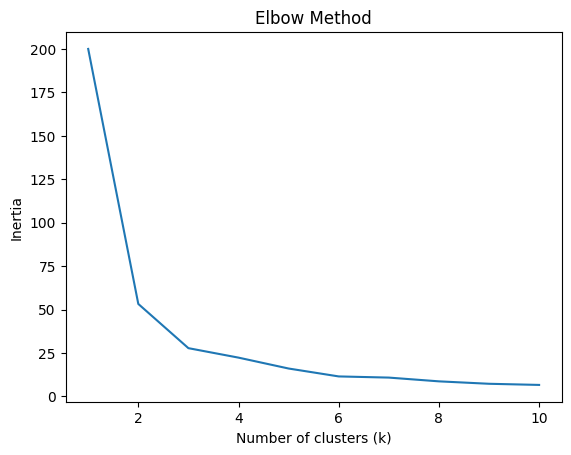

In [70]:
x_scaled = 'x_noise_standard'
y_scaled = 'y_noise_new_standard'
inertia = []
for i in range(1, 11): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(df_1[[x_scaled, y_scaled]])
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [71]:
# Inicializar uma lista vazia que vai conter os valores da silueta média
siluetas = []
# Este é o número máximo de grupos que vamos testar
max_clusters = 10

# O loop percorre de 2 até o máximo de clusters
for n_clusters in range(2, max_clusters+1):
    # Aqui rodamos o k-means
    km = KMeans(n_clusters=n_clusters).fit(df_1[[x_scaled, y_scaled]])
    # Aqui calculamos a silueta e guardamos o resultado na lista 'siluetas'
    siluetas.append(silhouette_score(df_1[[x_scaled, y_scaled]], km.labels_))
siluetas[:5]

[0.6204019133803809,
 0.5371422175305763,
 0.4715570282861898,
 0.4448630240612772,
 0.4590159092690868]

In [72]:
df_silueta = pd.DataFrame({'n_clusters': list(range(2, max_clusters+1)), 'silhueta_média': siluetas})
df_silueta

,n_clusters,silhueta_média
0,2,0.620402
1,3,0.537142
2,4,0.471557
3,5,0.444863
4,6,0.459016
5,7,0.426202
6,8,0.429800
7,9,0.386324
8,10,0.423380


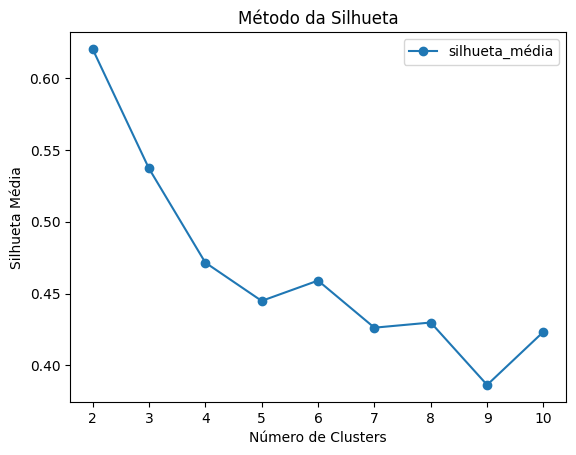

In [73]:
df_silueta.plot.line(
    x='n_clusters',
    y='silhueta_média',
    marker='o'
)
plt.title('Método da Silhueta')
plt.ylabel('Silhueta Média')
plt.xlabel('Número de Clusters')
plt.show()

In [74]:
optimal_k = df_silueta[df_silueta['silhueta_média'] == df_silueta['silhueta_média'].max()]['n_clusters'].values[0]
optimal_k

2

In [75]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans.fit(df_1[df_1.columns[-2:]])

KMeans(n_clusters=2, random_state=42)

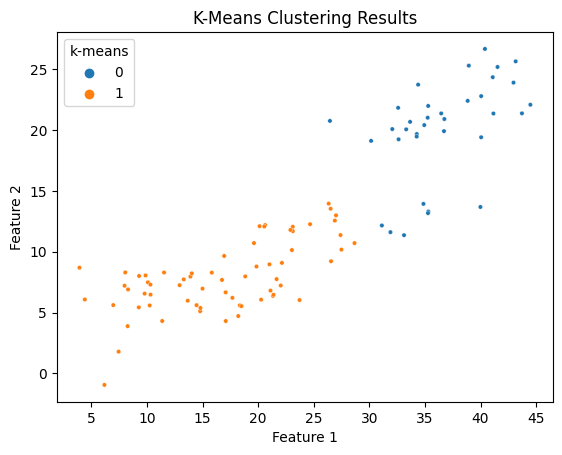

In [76]:
df_1['k-means'] = [1 if i == 0 else 0 for i in kmeans.labels_]
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    hue='k-means',
    data=df_1
)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering Results')
plt.show()

In [77]:
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_normalized,y_noise_new_normalized,x_noise_standard,y_noise_new_standard,k-means
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,0.916617,0.915897,1.573645,1.831463,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,0.146587,0.325856,-1.254069,-0.614858,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,0.808425,0.755305,1.176342,1.165645,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,0.231381,0.314201,-0.942684,-0.663181,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,0.339193,0.259145,-0.546779,-0.891444,1


In [78]:
def calcular_metricas(x: str, y: str, target: str, df: pd.DataFrame) -> None:
    '''
        Função para calcular métricas de avaliação de clustering.
            Parametros:
                x: str -> coluna que representa a primeira dimensão dos dados
                y: str -> coluna que representa a segunda dimensão dos dados
                target: str -> coluna que representa os rótulos dos clusters
                df: pd.DataFrame -> DataFrame contendo os dados
            Retorna:
                None -> apenas imprime as métricas calculadas
    '''
    print(f"Calculando métricas para o target: {target}\n")
    # Calcula a métrica de Silhouette 
    ss = round(silhouette_score(df[[x, y]], df[target]), 3)
    print(f"Silhouette Score -> {ss}")

    # Calcula a métrica de Calinski-Harabasz
    chs = round(calinski_harabasz_score(df[[x, y]], df[target]), 3)
    print(f"Calinski Harabasz Score -> {chs}")

    # Calcula a métrica de Davies-Bouldin
    dbs = round(davies_bouldin_score(df[[x, y]], df[target]), 3)
    print(f"Davies Bouldin Score -> {dbs}")

    # adjusted_rand_score(
    #     dados['x'],
    #     dados['x_noise_mean'],
    # )

    # adjusted_mutual_info_score(
    #     dados['x'],
    #     dados['x_noise_mean'],
    # )
    return None

In [79]:
metricas = {
    'x': x_scaled,
    'y': y_scaled,
    'target': 'k-means',
    'df': df_1
}
calcular_metricas(**metricas)

Calculando métricas para o target: k-means

Silhouette Score -> 0.62
Calinski Harabasz Score -> 270.218
Davies Bouldin Score -> 0.503


## DBSCAM

In [80]:
from sklearn.cluster import DBSCAN

In [81]:
# Create a DBSCAN instance with specified parameters
min_samples = [1, 2, 3, 4, 5, 6]
eps = [0.1, 0.2, 0.25, 0.3, 0.4, 0.5]

for sample in min_samples:
    for ep in eps:
        db = DBSCAN(eps=ep, min_samples=sample)
        # Fit the model to the data and predict cluster labels
        clusters = db.fit_predict(df_1[[x_scaled, y_scaled]])
        cluster, num = np.unique(clusters, return_counts=True)
        if len(cluster) == 2 or len(cluster) == 3:
            print("-----"*20)
            print(f"DBSCAN with eps={ep} and min_samples={sample}")
            print(cluster, num)

----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.5 and min_samples=1
[0 1] [28 72]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.4 and min_samples=2
[-1  0  1] [ 3 27 70]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.5 and min_samples=2
[0 1] [28 72]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.4 and min_samples=3
[-1  0  1] [ 3 27 70]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.5 and min_samples=3
[0 1] [28 72]
----------------------------------------------------------------------------------------------------
DBSCAN with eps=0.1 and min_samples=4
[-1  0  1] [92  4  4]
----------------------------------------------------------

In [82]:
db = DBSCAN(eps=0.3, min_samples=4)
# Fit the model to the data and predict cluster labels
df_1['DBSCAN_1'] = db.fit_predict(df_1[[x_scaled, y_scaled]])

db = DBSCAN(eps=0.5, min_samples=3)
# Fit the model to the data and predict cluster labels
df_1['DBSCAN_2'] = db.fit_predict(df_1[[x_scaled, y_scaled]])
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_normalized,y_noise_new_normalized,x_noise_standard,y_noise_new_standard,k-means,DBSCAN_1,DBSCAN_2
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,0.916617,0.915897,1.573645,1.831463,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,0.146587,0.325856,-1.254069,-0.614858,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,0.808425,0.755305,1.176342,1.165645,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,0.231381,0.314201,-0.942684,-0.663181,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,0.339193,0.259145,-0.546779,-0.891444,1,1,1


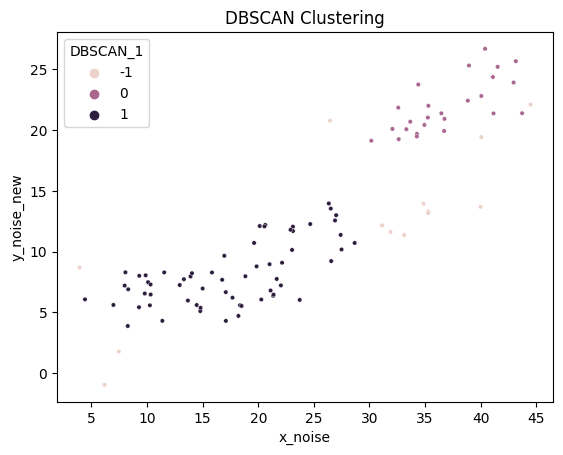

In [83]:
# Visualize the results
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    hue='DBSCAN_1',
    data=df_1
)
plt.title("DBSCAN Clustering")
plt.xlabel(x)
plt.ylabel(y)
plt.show()

In [84]:
metricas = {
    'x': x_scaled,
    'y': y_scaled,
    'target': 'DBSCAN_1',
    'df': df_1
}
calcular_metricas(**metricas)

Calculando métricas para o target: DBSCAN_1

Silhouette Score -> 0.47
Calinski Harabasz Score -> 101.352
Davies Bouldin Score -> 1.402


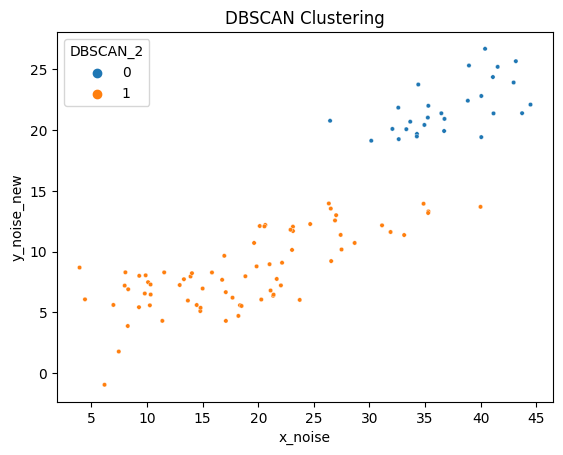

In [85]:
# Visualize the results
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    hue='DBSCAN_2',
    data=df_1
)
plt.title("DBSCAN Clustering")
plt.xlabel(x)
plt.ylabel(y)
plt.show()

In [86]:
metricas = {
    'x': x_scaled,
    'y': y_scaled,
    'target': 'DBSCAN_2',
    'df': df_1
}
calcular_metricas(**metricas)

Calculando métricas para o target: DBSCAN_2

Silhouette Score -> 0.61
Calinski Harabasz Score -> 217.816
Davies Bouldin Score -> 0.466


## Redes Neurais

In [87]:
import tensorflow as tf
from tensorflow import keras

In [88]:
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_normalized,y_noise_new_normalized,x_noise_standard,y_noise_new_standard,k-means,DBSCAN_1,DBSCAN_2
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,0.916617,0.915897,1.573645,1.831463,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,0.146587,0.325856,-1.254069,-0.614858,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,0.808425,0.755305,1.176342,1.165645,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,0.231381,0.314201,-0.942684,-0.663181,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,0.339193,0.259145,-0.546779,-0.891444,1,1,1


In [89]:
# Sample data
data = df_1[[
    'x',
    'y',
    'x_noise',
    'y_noise',
    'y_noise_new',
    'x_noise_mean',
    'y_noise_mean',
    'x_noise_standard',
    'y_noise_new_standard',
    'x_noise_normalized',
    'y_noise_new_normalized'
]]

# Build an autoencoder
input_dim = data.shape[1]
encoding_dim = 2 # Reduced dimension for clustering
input_dim

11

In [90]:
input_layer = keras.layers.Input(shape=(input_dim,))
encoder = keras.layers.Dense(encoding_dim, activation='relu')(input_layer)
decoder = keras.layers.Dense(input_dim, activation='sigmoid')(encoder)

autoencoder = keras.Model(inputs=input_layer, outputs=decoder)
encoder_model = keras.Model(inputs=input_layer, outputs=encoder)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 11)]              0         
                                                                 
 dense_2 (Dense)             (None, 2)                 24        
                                                                 
 dense_3 (Dense)             (None, 11)                33        
                                                                 
Total params: 57
Trainable params: 57
Non-trainable params: 0
_________________________________________________________________


In [91]:
autoencoder.fit(data, data, epochs=50, batch_size=32)

Epoch 1/50
4/4 [==============================] - 1s 5ms/step - loss: 227.0260
Epoch 2/50
4/4 [==============================] - 0s 3ms/step - loss: 226.9386
Epoch 3/50
4/4 [==============================] - 0s 3ms/step - loss: 226.8441
Epoch 4/50
4/4 [==============================] - 0s 3ms/step - loss: 226.7246
Epoch 5/50
4/4 [==============================] - 0s 3ms/step - loss: 226.5816
Epoch 6/50
4/4 [==============================] - 0s 2ms/step - loss: 226.4211
Epoch 7/50
4/4 [==============================] - 0s 3ms/step - loss: 226.2575
Epoch 8/50
4/4 [==============================] - 0s 4ms/step - loss: 226.0862
Epoch 9/50
4/4 [==============================] - 0s 3ms/step - loss: 225.9061
Epoch 10/50
4/4 [==============================] - 0s 3ms/step - loss: 225.7278
Epoch 11/50
4/4 [==============================] - 0s 3ms/step - loss: 225.5540
Epoch 12/50
4/4 [==============================] - 0s 5ms/step - loss: 225.3798
Epoch 13/50
4/4 [==============================] 

In [92]:
# Get the encoded representation
encoded_data = encoder_model.predict(data)
encoded_data[:3]

4/4 [==============================] - 0s 2ms/step


array([[33.93432 ,  0.      ],
       [13.498719,  0.      ],
       [28.425179,  0.      ]], dtype=float32)

In [93]:
for i in df_1.columns[-3:]:
    metricas = {
        'x': x_scaled,
        'y': y_scaled,
        'target': i,
        'df': df_1
    }
    calcular_metricas(**metricas)
    print("-----"*20)

Calculando métricas para o target: k-means

Silhouette Score -> 0.62
Calinski Harabasz Score -> 270.218
Davies Bouldin Score -> 0.503
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_1

Silhouette Score -> 0.47
Calinski Harabasz Score -> 101.352
Davies Bouldin Score -> 1.402
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_2

Silhouette Score -> 0.61
Calinski Harabasz Score -> 217.816
Davies Bouldin Score -> 0.466
----------------------------------------------------------------------------------------------------


In [94]:
db = DBSCAN(eps=0.3, min_samples=4)
# Fit the model to the data and predict cluster labels
clusters = db.fit_predict(df_1[[x_scaled, y_scaled]])
df_1['NN-DBSCAN_1'] = clusters
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_normalized,y_noise_new_normalized,x_noise_standard,y_noise_new_standard,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,0.916617,0.915897,1.573645,1.831463,0,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,0.146587,0.325856,-1.254069,-0.614858,1,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,0.808425,0.755305,1.176342,1.165645,0,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,0.231381,0.314201,-0.942684,-0.663181,1,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,0.339193,0.259145,-0.546779,-0.891444,1,1,1,1


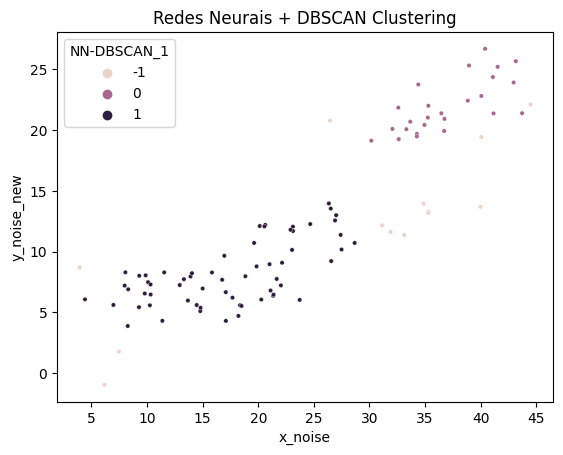

In [95]:
# Visualize the results
sns.scatterplot(
    x=x,
    y=y,
    s=s,
    hue='NN-DBSCAN_1',
    data=df_1
)
plt.title("Redes Neurais + DBSCAN Clustering")
plt.xlabel(x)
plt.ylabel(y)
plt.show()

In [96]:
# dump(df_1, './data/05_aula_df_3')

In [97]:
df_1 = load('./data/05_aula_df_3')
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_normalized,y_noise_new_normalized,x_noise_standard,y_noise_new_standard,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,0.916617,0.915897,1.573645,1.831463,0,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,0.146587,0.325856,-1.254069,-0.614858,1,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,0.808425,0.755305,1.176342,1.165645,0,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,0.231381,0.314201,-0.942684,-0.663181,1,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,0.339193,0.259145,-0.546779,-0.891444,1,1,1,1


In [98]:
for i in df_1.columns[-4:]:
    metricas = {
        'x': x_scaled,
        'y': y_scaled,
        'target': i,
        'df': df_1
    }
    calcular_metricas(**metricas)
    print("-----"*20)

Calculando métricas para o target: k-means

Silhouette Score -> 0.62
Calinski Harabasz Score -> 270.218
Davies Bouldin Score -> 0.503
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_1

Silhouette Score -> 0.47
Calinski Harabasz Score -> 101.352
Davies Bouldin Score -> 1.402
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_2

Silhouette Score -> 0.61
Calinski Harabasz Score -> 217.816
Davies Bouldin Score -> 0.466
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: NN-DBSCAN_1

Silhouette Score -> 0.47
Calinski Harabasz Score -> 101.352
Davies Bouldin Score -> 1.402
----------------------------------------------------------------------------------------------------


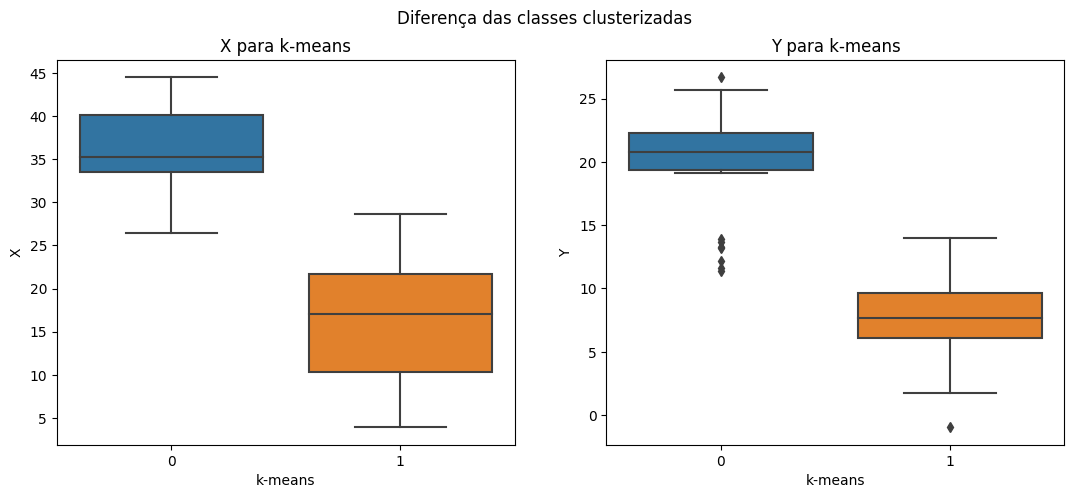

In [99]:
x_cluster = 'k-means'
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle('Diferença das classes clusterizadas')
g = sns.boxplot(
    x=x_cluster,
    y=x,
    data=df_1,
    ax=ax[0]
)
g.set(
    title = 'X para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'X',
)
g = sns.boxplot(
    x=x_cluster,
    y=y,
    data=df_1,
    ax=ax[1]
)
g.set(
    title = 'Y para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'Y',
)
plt.show()

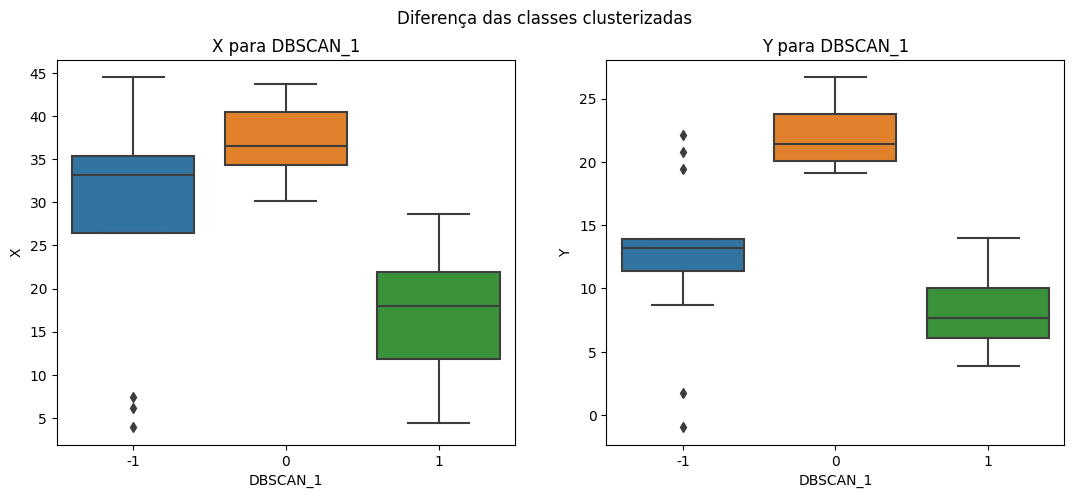

In [100]:
x_cluster = 'DBSCAN_1'
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle('Diferença das classes clusterizadas')
g = sns.boxplot(
    x=x_cluster,
    y=x,
    data=df_1,
    ax=ax[0]
)
g.set(
    title = 'X para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'X',
)
g = sns.boxplot(
    x=x_cluster,
    y=y,
    data=df_1,
    ax=ax[1]
)
g.set(
    title = 'Y para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'Y',
)
plt.show()

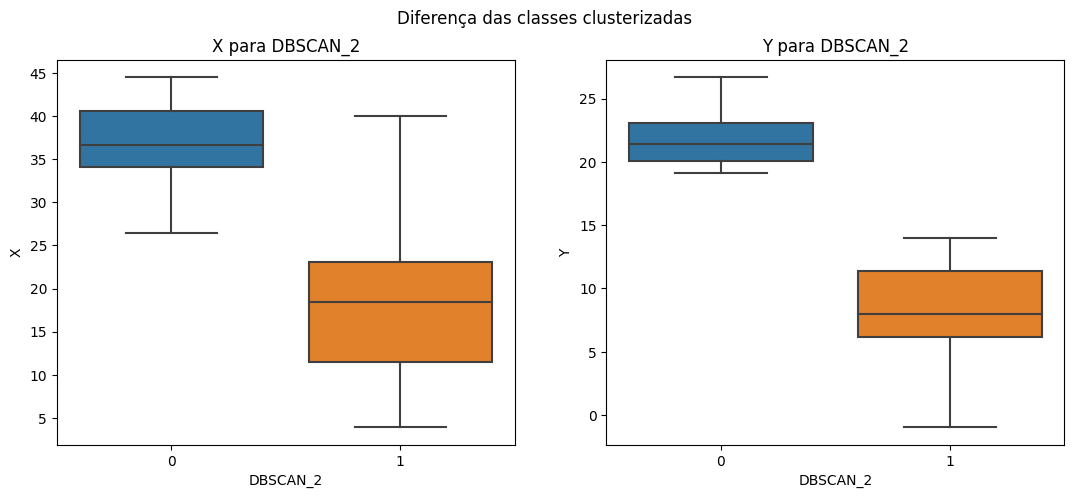

In [101]:
x_cluster = 'DBSCAN_2'
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle('Diferença das classes clusterizadas')
g = sns.boxplot(
    x=x_cluster,
    y=x,
    data=df_1,
    ax=ax[0]
)
g.set(
    title = 'X para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'X',
)
g = sns.boxplot(
    x=x_cluster,
    y=y,
    data=df_1,
    ax=ax[1]
)
g.set(
    title = 'Y para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'Y',
)
plt.show()

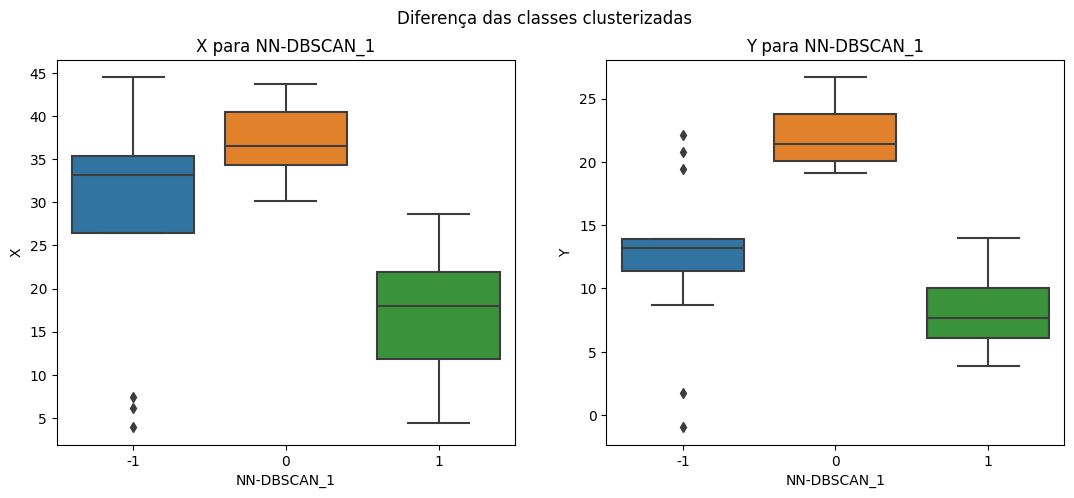

In [102]:
x_cluster = 'NN-DBSCAN_1'
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.suptitle('Diferença das classes clusterizadas')
g = sns.boxplot(
    x=x_cluster,
    y=x,
    data=df_1,
    ax=ax[0]
)
g.set(
    title = 'X para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'X',
)
g = sns.boxplot(
    x=x_cluster,
    y=y,
    data=df_1,
    ax=ax[1]
)
g.set(
    title = 'Y para '+x_cluster,
    xlabel = x_cluster,
    ylabel = 'Y',
)
plt.show()

In [103]:
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,x_noise_normalized,y_noise_new_normalized,x_noise_standard,y_noise_new_standard,k-means,DBSCAN_1,DBSCAN_2,NN-DBSCAN_1
53,41,18,41.101260,19.359319,24.359319,23,8,False,o,+,0.916617,0.915897,1.573645,1.831463,0,0,0,0
93,9,2,9.876045,3.050423,8.050423,23,9,True,+,o,0.146587,0.325856,-1.254069,-0.614858,1,1,1,1
20,37,16,36.714018,14.920509,19.920509,11,0,False,o,+,0.808425,0.755305,1.176342,1.165645,0,0,0,0
177,15,5,13.314530,2.728269,7.728269,42,21,False,o,o,0.231381,0.314201,-0.942684,-0.663181,1,1,1,1
26,15,5,17.686336,1.206506,6.206506,9,5,False,o,o,0.339193,0.259145,-0.546779,-0.891444,1,1,1,1


In [104]:
def calcular_metricas_ajustadas(pred: str, df: pd.DataFrame, obsr: str = 'DBSCAN_1') -> None:
    print(f"Calculando métricas para o target: {pred}\n")
    # Calcula a métrica de Adjusted Rand Score
    ari = round(adjusted_rand_score(df[obsr], df[pred]), 3)
    print(f"Adjusted Rand Score -> {ari}")

    # Calcula a métrica de Adjusted Mutual Info Score
    ami = round(adjusted_mutual_info_score(df[obsr], df[pred]), 3)
    print(f"Adjusted Mutual Info Score -> {ami}")

    return None

In [105]:
for i in df_1.columns[-4:]:
    metricas = {
        'pred': i,
        'df': df_1
    }
    calcular_metricas_ajustadas(**metricas)
    print("-----"*20)

Calculando métricas para o target: k-means

Adjusted Rand Score -> 0.813
Adjusted Mutual Info Score -> 0.739
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_1

Adjusted Rand Score -> 1.0
Adjusted Mutual Info Score -> 1.0
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_2

Adjusted Rand Score -> 0.712
Adjusted Mutual Info Score -> 0.692
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: NN-DBSCAN_1

Adjusted Rand Score -> 1.0
Adjusted Mutual Info Score -> 1.0
----------------------------------------------------------------------------------------------------


In [106]:
for i in df_1.columns[-4:]:
    metricas = {
        'pred': i,
        'obsr': 'k-means',
        'df': df_1
    }
    calcular_metricas_ajustadas(**metricas)
    print("-----"*20)

Calculando métricas para o target: k-means

Adjusted Rand Score -> 1.0
Adjusted Mutual Info Score -> 1.0
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_1

Adjusted Rand Score -> 0.813
Adjusted Mutual Info Score -> 0.739
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: DBSCAN_2

Adjusted Rand Score -> 0.733
Adjusted Mutual Info Score -> 0.671
----------------------------------------------------------------------------------------------------
Calculando métricas para o target: NN-DBSCAN_1

Adjusted Rand Score -> 0.813
Adjusted Mutual Info Score -> 0.739
----------------------------------------------------------------------------------------------------
